=== Path Check ===
  OK      S1Hand                     → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                  → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING Weak S1 (unlabeled pool)   → None
  MISSING Weak label masks           → None

Deriving image-level labels from masks (flooded = water fraction ≥ 0.01) ...
  Chips: 441  (293 flooded | 148 non-flooded)

=== Training Sets (identical across all seeds) ===
  Supervised-only  : 176 chips  (121 flooded | 55 non-flooded)
  Full-supervision : 352 chips  (234 flooded | 118 non-flooded)
  Val              : 89 chips

Device  : cuda
GPU     : Tesla T4
Runs    : 2 baselines × 3 seeds [42, 123, 2024] × 50 epochs (dense only, NO pruning)


████████████████████████████████████████████████████████████████████████████████████████
  SEED-VARIANCE CHECK  —  VGG-16 dense  |  SEN1FLOODS11
████████

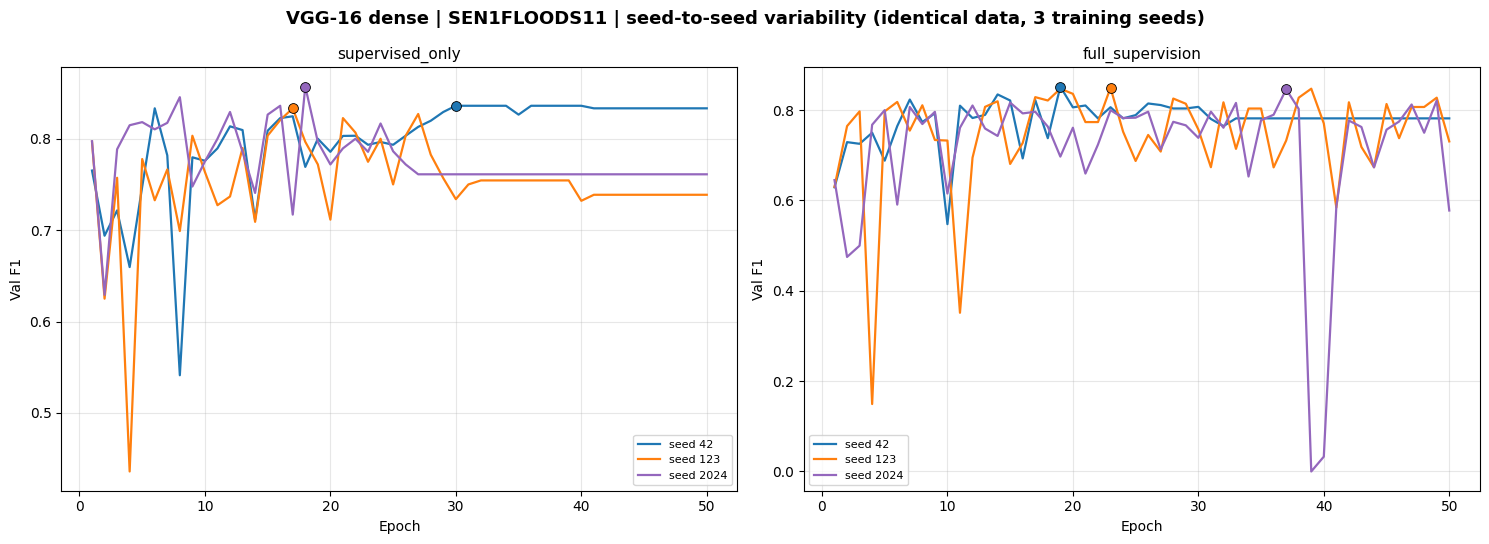

Saved → vgg16_sen1floods11_seed_variance_curves.png

✓ All done.


In [2]:
import os, copy, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

# ── 0. Seeds ───────────────────────────────────────────────────────────
DATA_SEED = 42                    # fixed → identical splits in every run
RUN_SEEDS = [42, 123, 2024]       # vary ONLY training randomness

random.seed(DATA_SEED); np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(DATA_SEED)

# ── 1. PATHS — auto-detect the dataset layout ──────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download("smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    """Walk directories only (cheap) and return the first match by name."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR        = find_dir(ROOT, "S1Hand")
LABEL_DIR     = find_dir(ROOT, "LabelHand")
WEAK_DIR      = find_dir(ROOT, "S1Weak")            # weakly-labeled S1 chips
WEAK_LBL_DIR  = (find_dir(ROOT, "S1OtsuLabelWeak")  # weak reference masks
                 or find_dir(ROOT, "S2IndexLabelWeak"))

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("Weak S1 (unlabeled pool)", WEAK_DIR),
                ("Weak label masks", WEAK_LBL_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<26} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None, \
    "Could not locate S1Hand / LabelHand folders — check dataset root."

# ── 2. Derive image-level labels from pixel masks ──────────────────────
#  (identical constants and RNG call order to the baseline script,
#   seeded with DATA_SEED=42 → chip-for-chip identical splits)
FLOOD_THRESHOLD    = 0.01   # chip = flooded if ≥1% of valid pixels are water
UNLABELED_FRACTION = 0.50   # fallback only (when no weak S1 folder exists)
MAX_UNLABELED      = 1500   # cap unlabeled pool (RAM guard)

def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print("\nDeriving image-level labels from masks "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")

all_samples = []                      # (s1_path, label)
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:                    # chip is entirely no-data
        continue
    all_samples.append((str(s1_path), int(wf >= FLOOD_THRESHOLD)))

flooded_s    = [s for s in all_samples if s[1] == 1]
nonflooded_s = [s for s in all_samples if s[1] == 0]
print(f"  Chips: {len(all_samples)}  "
      f"({len(flooded_s)} flooded | {len(nonflooded_s)} non-flooded)")

# ── 3. 80/20 labeled split (same RNG order as before) ──────────────────
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

TRAIN_SAMPLES = f_train + nf_train
VAL_SAMPLES   = f_val   + nf_val

# ── 4. Unlabeled pool (same RNG order as before) ───────────────────────
if WEAK_DIR is not None:
    UNLABELED_PATHS = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(UNLABELED_PATHS)
    UNLABELED_PATHS = UNLABELED_PATHS[:MAX_UNLABELED]
else:
    random.shuffle(TRAIN_SAMPLES)
    cut             = int((1 - UNLABELED_FRACTION) * len(TRAIN_SAMPLES))
    UNLABELED_PATHS = [p for p, _ in TRAIN_SAMPLES[cut:]]
    HIDDEN_TRUE     = {p: l for p, l in TRAIN_SAMPLES[cut:]}
    TRAIN_SAMPLES   = TRAIN_SAMPLES[:cut]

UNLABELED_TRUE = {}
if WEAK_DIR is None:
    UNLABELED_TRUE = HIDDEN_TRUE
elif WEAK_LBL_DIR is not None:
    weak_suffix = f"_{WEAK_LBL_DIR.name}.tif"
    s1w_suffix  = f"_{WEAK_DIR.name}.tif"
    for p in UNLABELED_PATHS:
        stem = Path(p).name.replace(s1w_suffix, "")
        wm   = WEAK_LBL_DIR / f"{stem}{weak_suffix}"
        if not wm.exists():
            continue
        wf = water_fraction(wm)
        if wf is not None:
            UNLABELED_TRUE[p] = int(wf >= FLOOD_THRESHOLD)

# ── 5. The two baseline training sets ──────────────────────────────────
SUPERVISED_ONLY_SET  = list(TRAIN_SAMPLES)
FULL_SUPERVISION_SET = list(TRAIN_SAMPLES) + \
    [(p, UNLABELED_TRUE[p]) for p in UNLABELED_PATHS if p in UNLABELED_TRUE]

def class_counts(samples):
    f  = sum(1 for _, l in samples if l == 1)
    nf = sum(1 for _, l in samples if l == 0)
    return f, nf

print(f"\n=== Training Sets (identical across all seeds) ===")
for name, s in [("Supervised-only", SUPERVISED_ONLY_SET),
                ("Full-supervision", FULL_SUPERVISION_SET)]:
    f, nf = class_counts(s)
    print(f"  {name:<17}: {len(s)} chips  ({f} flooded | {nf} non-flooded)")
print(f"  Val              : {len(VAL_SAMPLES)} chips")

# ── 6. Hyper-parameters (identical to baselines) ───────────────────────
IMG_SIZE  = 224
BATCH     = 16
LR        = 1e-4
E         = 50
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nDevice  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Runs    : 2 baselines × {len(RUN_SEEDS)} seeds "
      f"{RUN_SEEDS} × {E} epochs (dense only, NO pruning)")

# ── 7. SAR chip loading → 3-channel tensor (identical) ─────────────────
DB_MIN, DB_MAX = -50.0, 1.0
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    """2-band SAR GeoTIFF → normalized 3×224×224 float tensor."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    arr = np.nan_to_num(arr, nan=DB_MIN)
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

class LabeledDS(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return load_s1_tensor(path), torch.tensor(lbl, dtype=torch.float32)

val_ldr = DataLoader(LabeledDS(VAL_SAMPLES), batch_size=BATCH,
                     shuffle=False, num_workers=2, pin_memory=True)

def make_train_loader(samples):
    f, nf = class_counts(samples)
    n     = len(samples)
    cw    = [n/(2*nf), n/(2*f)]
    sw    = [cw[int(l)] for _, l in samples]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(LabeledDS(samples), batch_size=BATCH, sampler=sampler,
                      num_workers=2, pin_memory=True)

# ── 8. Build VGG-16 (identical) ────────────────────────────────────────
def build_vgg16():
    m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(4096, 1)   # 4096 → 1
    return m

# ── 9. Evaluation (identical) ──────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 10. One dense training run with a given seed ───────────────────────
def train_dense(run_name, samples, seed):
    """Plain supervised training, E epochs. The seed controls ONLY
    training randomness (FC init, dropout, sampler, batch order) —
    the data split was already fixed with DATA_SEED before this call."""
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    model     = build_vgg16().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    train_ldr = make_train_loader(samples)

    history  = []
    best_f1, best_epoch, best_row = -1, -1, {}

    print(f"\n{'═'*88}")
    print(f"  VGG-16 dense  |  {run_name}  |  seed {seed}  |  "
          f"{len(samples)} train chips  |  {E} epochs")
    print(f"{'═'*88}")
    print(f"{'Ep':>3} │ {'Loss':>8} │ {'Acc':>6} │ {'F1':>6} │ "
          f"{'Prec':>6} │ {'Rec':>6} │ {'AUC':>6}")
    print(f"{'─'*88}")

    for ep in range(E):
        model.train()
        total_loss, n_batches = 0.0, 0
        for imgs, lbls in train_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        acc, f1, prec, rec, roc = evaluate(model, val_ldr)

        row = dict(run=run_name, seed=seed, epoch=ep+1,
                   loss=round(avg_loss,4), accuracy=round(acc,4),
                   f1=round(f1,4), precision=round(prec,4),
                   recall=round(rec,4), roc_auc=round(roc,4))
        history.append(row)

        print(f"{ep+1:3d} │ {avg_loss:8.4f} │ {acc:6.4f} │ {f1:6.4f} │ "
              f"{prec:6.4f} │ {rec:6.4f} │ {roc:6.4f}")

        if f1 > best_f1:
            best_f1 = f1; best_epoch = ep+1
            best_row = row.copy()

    print(f"{'─'*88}")
    print(f"  ★ seed {seed} best epoch {best_epoch}  |  "
          f"Acc={best_row['accuracy']:.4f}  F1={best_row['f1']:.4f}  "
          f"AUC={best_row['roc_auc']:.4f}")

    del model
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    return history, best_row

# ── 11. Run: 2 baselines × 3 seeds ─────────────────────────────────────
print("\n\n" + "█"*88)
print("  SEED-VARIANCE CHECK  —  VGG-16 dense  |  SEN1FLOODS11")
print("█"*88)

RUNS = [("supervised_only",  SUPERVISED_ONLY_SET),
        ("full_supervision", FULL_SUPERVISION_SET)]

all_history = []
best_rows   = []

for run_name, samples in RUNS:
    for seed in RUN_SEEDS:
        hist, best = train_dense(run_name, samples, seed)
        all_history.extend(hist)
        best_rows.append(best)

# ── 12. Variance summary — the number the lead asked for ──────────────
best_df = pd.DataFrame(best_rows)

print("\n\n" + "═"*88)
print("  SEED-VARIANCE SUMMARY — best val F1 per run (dense, no pruning)")
print("═"*88)
print(f"{'Run':<18} │ {'Seed':>6} │ {'Epoch':>5} │ {'Acc':>6} │ "
      f"{'F1':>6} │ {'AUC':>6}")
print("─"*88)
for _, r in best_df.iterrows():
    print(f"{r['run']:<18} │ {r['seed']:>6} │ {r['epoch']:>5} │ "
          f"{r['accuracy']:>6.4f} │ {r['f1']:>6.4f} │ {r['roc_auc']:>6.4f}")
print("─"*88)

spread_rows = []
for run_name, _ in RUNS:
    sub = best_df[best_df["run"] == run_name]
    for col in ["accuracy", "f1", "roc_auc"]:
        spread_rows.append(dict(
            run=run_name, metric=col,
            mean=round(sub[col].mean(), 4),
            std=round(sub[col].std(), 4),
            min=round(sub[col].min(), 4),
            max=round(sub[col].max(), 4),
            spread=round(sub[col].max() - sub[col].min(), 4)))
spread_df = pd.DataFrame(spread_rows)

print("\n  Spread across seeds (max − min):")
print(f"{'Run':<18} │ {'Metric':<9} │ {'Mean':>7} │ {'Std':>7} │ "
      f"{'Min':>7} │ {'Max':>7} │ {'SPREAD':>7}")
print("─"*88)
for _, r in spread_df.iterrows():
    print(f"{r['run']:<18} │ {r['metric']:<9} │ {r['mean']:>7.4f} │ "
          f"{r['std']:>7.4f} │ {r['min']:>7.4f} │ {r['max']:>7.4f} │ "
          f"{r['spread']:>7.4f}")
print("═"*88)
print("\nHow to read this:")
print("  • Compare the F1 SPREAD against the pruning-vs-dense deltas")
print("    (e.g. the +3.4% of unstructured@90%).")
print("  • SPREAD ≥ delta  → the pruning effect is within seed noise.")
print("  • SPREAD ≪ delta  → the effect is real and worth explaining.")

# ── 13. Save ───────────────────────────────────────────────────────────
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
hist_df = pd.DataFrame(all_history)
hist_df.to_csv(f"{OUT}/vgg16_sen1floods11_seed_variance_history.csv",
               index=False)
best_df.to_csv(f"{OUT}/vgg16_sen1floods11_seed_variance_best.csv",
               index=False)
spread_df.to_csv(f"{OUT}/vgg16_sen1floods11_seed_variance_spread.csv",
                 index=False)
print(f"\nSaved → vgg16_sen1floods11_seed_variance_history.csv")
print(f"Saved → vgg16_sen1floods11_seed_variance_best.csv")
print(f"Saved → vgg16_sen1floods11_seed_variance_spread.csv")

# ── 14. Plot — F1 curves for all seeds, per baseline ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("VGG-16 dense | SEN1FLOODS11 | seed-to-seed variability "
             "(identical data, 3 training seeds)",
             fontsize=13, fontweight="bold")
seed_colors = ["tab:blue", "tab:orange", "tab:purple"]

for ax, (run_name, _) in zip(axes, RUNS):
    for seed, c in zip(RUN_SEEDS, seed_colors):
        sub = hist_df[(hist_df["run"] == run_name) &
                      (hist_df["seed"] == seed)]
        ax.plot(sub["epoch"], sub["f1"], color=c, linewidth=1.6,
                label=f"seed {seed}")
        b = best_df[(best_df["run"] == run_name) &
                    (best_df["seed"] == seed)].iloc[0]
        ax.scatter([b["epoch"]], [b["f1"]], color=c, s=50, zorder=5,
                   edgecolors="black", linewidths=0.6)
    ax.set_title(run_name, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val F1")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/vgg16_sen1floods11_seed_variance_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → vgg16_sen1floods11_seed_variance_curves.png")

print("\n✓ All done.")